✅ Libraries imported successfully!

LOADING DATA
✅ Hourly data loaded: (3679872, 60)
✅ Groups metadata loaded: (112, 8)
📊 Data overview:
   - Date range: 2021-01-01 00:00:00 to 2024-09-30 23:00:00
   - Number of groups: 112
   - Total hours: 3679872

DEFINING FEATURE SETS FOR 48-HOUR FORECAST
✅ Total features: 39
   - Time: 14
   - Lag: 6
   - Rolling: 6
   - Price: 3
   - Weather: 6
   - Group: 4

CREATING TRAIN/VALIDATION SPLIT
✅ Train set: 3599232 hours
   Date range: 2021-01-01 00:00:00 to 2024-08-31 23:00:00
✅ Validation set: 80640 hours
   Date range: 2024-09-01 00:00:00 to 2024-09-30 23:00:00

📊 Final shapes:
   X_train: (3599232, 39)
   X_val: (80640, 39)

TRAINING XGBOOST MODEL
⏳ Training XGBoost (this will take several minutes)...
[0]	validation_0-rmse:0.88364
[100]	validation_0-rmse:0.06085
[200]	validation_0-rmse:0.05570
[300]	validation_0-rmse:0.05341
[400]	validation_0-rmse:0.05195
[499]	validation_0-rmse:0.05113
✅ XGBoost trained!
   Best iteration: 499

TRAINING LIGHTGB

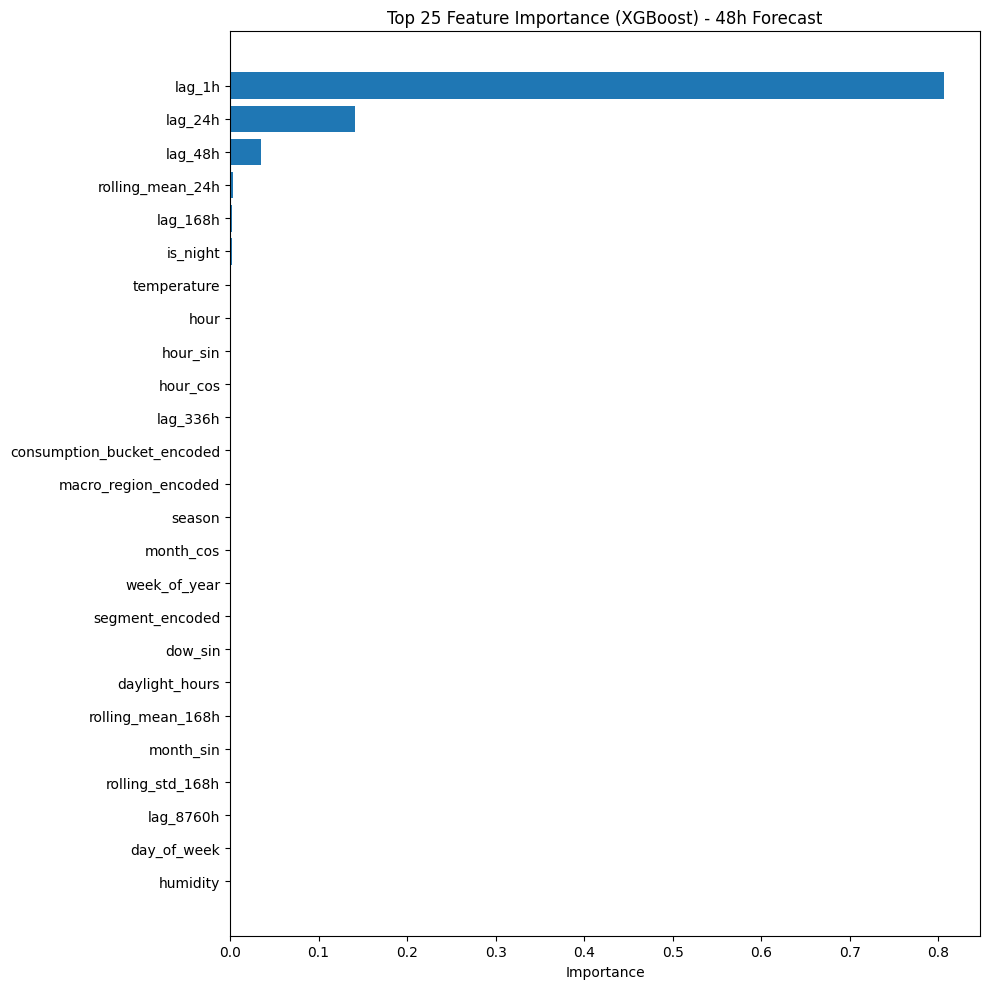


VISUALIZING PREDICTIONS
✅ Saved: hourly_predictions_validation.png


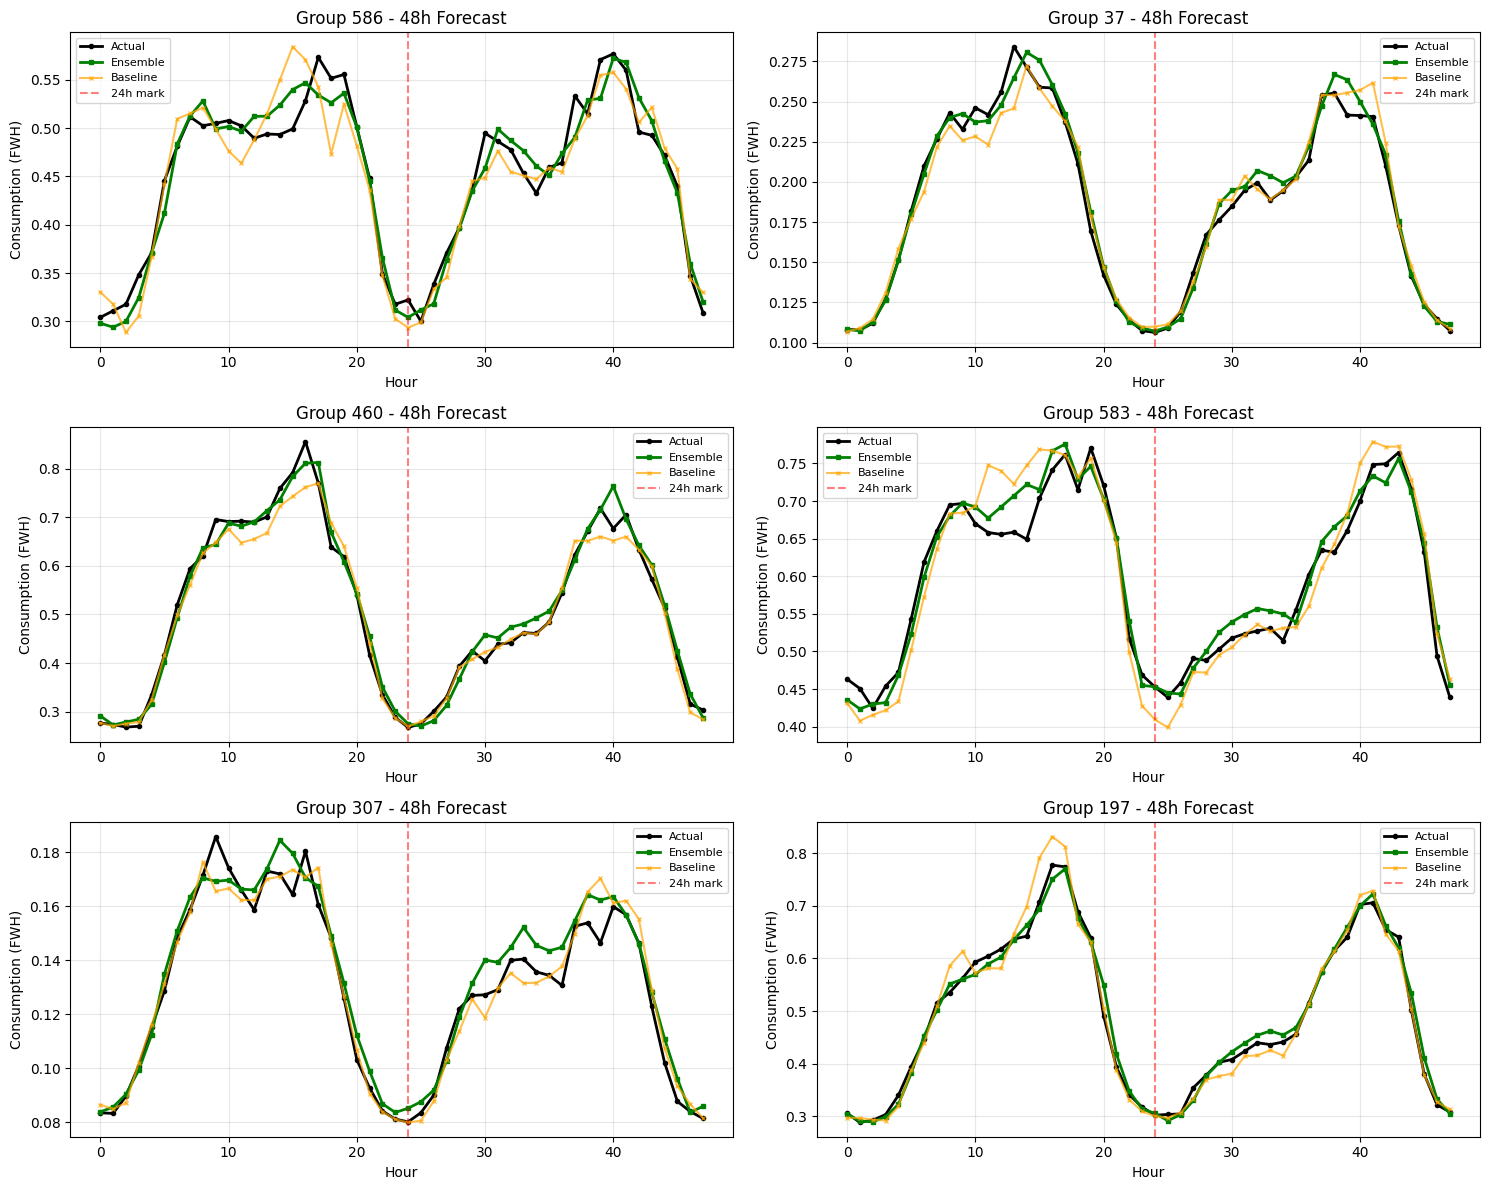


PREPARING TEST DATA FOR OCT 1-2, 2024
✅ Test period: 48 hours
   Start: 2024-10-01 00:00:00
   End: 2024-10-02 23:00:00
✅ Historical data up to: 2024-09-30 23:00:00

CREATING TEST FEATURES
⏳ Creating test features for each group...
   Progress: 20/112 groups
   Progress: 40/112 groups
   Progress: 60/112 groups
   Progress: 80/112 groups
   Progress: 100/112 groups

✅ Test data created: (5376, 41)

MAKING TEST PREDICTIONS
🔮 Predicting consumption for Oct 1-2, 2024...
✅ Predictions complete: 5376 values

FORMATTING FOR SUBMISSION
✅ Submission shape: (48, 113)

📋 Preview:
group_id         measured_at        28        29        30        36  \
0        2024-10-01 00:00:00  3.848584  0.100379  0.530785  0.294714   
1        2024-10-01 01:00:00  3.887856  0.102331  0.540903  0.299521   
2        2024-10-01 02:00:00  3.959830  0.113526  0.572995  0.322621   
3        2024-10-01 03:00:00  4.221123  0.124463  0.610636  0.344868   
4        2024-10-01 04:00:00  4.275478  0.139397  0.652870  0.

In [1]:
# ============================================================================
# 48-HOUR FORECASTING - XGBOOST + LIGHTGBM ENSEMBLE
# Same reliable approach as monthly forecasting!
# ============================================================================

# Step 1: Install Required Libraries
# ============================================================================
!pip install xgboost lightgbm scikit-learn -q

# Step 2: Import Libraries
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

# ============================================================================
# Step 3: Load Prepared Data
# ============================================================================
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load hourly data
df = pd.read_parquet('/content/drive/MyDrive/Junction2025/Data Preparation/fortum_prepared_full.parquet')
print(f"✅ Hourly data loaded: {df.shape}")

# Load groups metadata
groups_df = pd.read_csv('/content/drive/MyDrive/Junction2025/Data Preparation/groups_metadata.csv')
print(f"✅ Groups metadata loaded: {groups_df.shape}")

# Sort by group and time
df = df.sort_values(['group_id', 'measured_at']).reset_index(drop=True)

print(f"📊 Data overview:")
print(f"   - Date range: {df['measured_at'].min()} to {df['measured_at'].max()}")
print(f"   - Number of groups: {df['group_id'].nunique()}")
print(f"   - Total hours: {len(df)}")

# ============================================================================
# Step 4: Define Feature Sets
# ============================================================================
print("\n" + "="*80)
print("DEFINING FEATURE SETS FOR 48-HOUR FORECAST")
print("="*80)

# Time features
time_features = [
    'hour', 'day_of_week', 'month', 'week_of_year',
    'is_weekend', 'is_night', 'is_holiday', 'season',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

# Lag features (hourly)
lag_features = [
    'lag_1h', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_336h', 'lag_8760h'
]

# Rolling features
rolling_features = [
    'rolling_mean_24h', 'rolling_mean_168h', 'rolling_mean_720h',
    'rolling_std_24h', 'rolling_std_168h', 'rolling_std_720h'
]

# Price features
price_features = [
    'eur_per_mwh', 'price_lag_24h', 'price_lag_168h'
]

# Weather features (if available)
weather_features = []
if 'temperature' in df.columns:
    weather_features.extend(['temperature', 'humidity', 'precipitation',
                            'wind_speed', 'cloud_cover'])
if 'daylight_hours' in df.columns:
    weather_features.append('daylight_hours')

# Remove features not in dataframe
weather_features = [f for f in weather_features if f in df.columns]
price_features = [f for f in price_features if f in df.columns]
lag_features = [f for f in lag_features if f in df.columns]
rolling_features = [f for f in rolling_features if f in df.columns]

# Group features (encoded categorical)
group_features = [
    'macro_region_encoded', 'segment_encoded',
    'product_type_encoded', 'consumption_bucket_encoded'
]
group_features = [f for f in group_features if f in df.columns]

# Combine all features
all_features = (time_features + lag_features + rolling_features +
                price_features + weather_features + group_features)

# Filter out any missing features
all_features = [f for f in all_features if f in df.columns]

print(f"✅ Total features: {len(all_features)}")
print(f"   - Time: {len(time_features)}")
print(f"   - Lag: {len(lag_features)}")
print(f"   - Rolling: {len(rolling_features)}")
print(f"   - Price: {len(price_features)}")
print(f"   - Weather: {len(weather_features)}")
print(f"   - Group: {len(group_features)}")

# ============================================================================
# Step 5: Train/Validation Split
# ============================================================================
print("\n" + "="*80)
print("CREATING TRAIN/VALIDATION SPLIT")
print("="*80)

# Split date: Use September 2024 for validation
split_date = pd.Timestamp('2024-09-01')

# Create splits
train_data = df[df['measured_at'] < split_date].copy()
val_data = df[df['measured_at'] >= split_date].copy()

# Remove rows with missing values in features
train_data_clean = train_data.dropna(subset=all_features + ['consumption'])
val_data_clean = val_data.dropna(subset=all_features + ['consumption'])

print(f"✅ Train set: {len(train_data_clean)} hours")
print(f"   Date range: {train_data_clean['measured_at'].min()} to {train_data_clean['measured_at'].max()}")
print(f"✅ Validation set: {len(val_data_clean)} hours")
print(f"   Date range: {val_data_clean['measured_at'].min()} to {val_data_clean['measured_at'].max()}")

# Prepare X and y
X_train = train_data_clean[all_features]
y_train = train_data_clean['consumption']

X_val = val_data_clean[all_features]
y_val = val_data_clean['consumption']

print(f"\n📊 Final shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val: {X_val.shape}")

# ============================================================================
# Step 6: Train XGBoost Model
# ============================================================================
print("\n" + "="*80)
print("TRAINING XGBOOST MODEL")
print("="*80)

print("⏳ Training XGBoost (this will take several minutes)...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1,
    early_stopping_rounds=30,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f"✅ XGBoost trained!")
print(f"   Best iteration: {xgb_model.best_iteration}")

# ============================================================================
# Step 7: Train LightGBM Model
# ============================================================================
print("\n" + "="*80)
print("TRAINING LIGHTGBM MODEL")
print("="*80)

print("⏳ Training LightGBM...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    objective='regression',
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(100)]
)

print(f"✅ LightGBM trained!")

# ============================================================================
# Step 8: Make Validation Predictions
# ============================================================================
print("\n" + "="*80)
print("MAKING VALIDATION PREDICTIONS")
print("="*80)

# XGBoost predictions
xgb_pred = xgb_model.predict(X_val)

# LightGBM predictions
lgb_pred = lgb_model.predict(X_val)

# Ensemble (average)
ensemble_pred = 0.5 * xgb_pred + 0.5 * lgb_pred

print("✅ Predictions complete")

# ============================================================================
# Step 9: Calculate Metrics
# ============================================================================
print("\n" + "="*80)
print("CALCULATING METRICS")
print("="*80)

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE"""
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

def calculate_metrics(y_true, y_pred, model_name):
    """Calculate and print metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"\n📊 {model_name} Metrics:")
    print(f"   - MAE:  {mae:.4f}")
    print(f"   - RMSE: {rmse:.4f}")
    print(f"   - MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Calculate overall metrics
xgb_metrics = calculate_metrics(y_val, xgb_pred, "XGBoost")
lgb_metrics = calculate_metrics(y_val, lgb_pred, "LightGBM")
ensemble_metrics = calculate_metrics(y_val, ensemble_pred, "Ensemble")

# ============================================================================
# Step 10: Calculate Metrics by Horizon
# ============================================================================
print("\n" + "="*80)
print("CALCULATING METRICS BY TIME HORIZON")
print("="*80)

# Add predictions to validation data
val_data_clean['xgb_pred'] = xgb_pred
val_data_clean['lgb_pred'] = lgb_pred
val_data_clean['ensemble_pred'] = ensemble_pred

# Calculate metrics for different horizons
# For each group, look at predictions 1-24h ahead vs 25-48h ahead
horizon_metrics = []

for group_id in val_data_clean['group_id'].unique():
    group_val = val_data_clean[val_data_clean['group_id'] == group_id].sort_values('measured_at')

    # Split into chunks of 48 hours
    for i in range(0, len(group_val) - 48, 48):
        chunk = group_val.iloc[i:i+48]

        if len(chunk) == 48:
            # First 24 hours
            first_24 = chunk.iloc[:24]
            # Next 24 hours
            next_24 = chunk.iloc[24:48]

            # Calculate MAPE for each horizon
            mape_1_24 = mean_absolute_percentage_error(
                first_24['consumption'].values,
                first_24['ensemble_pred'].values
            )
            mape_25_48 = mean_absolute_percentage_error(
                next_24['consumption'].values,
                next_24['ensemble_pred'].values
            )

            horizon_metrics.append({
                'first_24h': mape_1_24,
                'next_24h': mape_25_48
            })

if horizon_metrics:
    horizon_df = pd.DataFrame(horizon_metrics)
    print(f"📊 Performance by Horizon:")
    print(f"   - First 24 hours MAPE:  {horizon_df['first_24h'].mean():.2f}%")
    print(f"   - Next 24 hours MAPE:   {horizon_df['next_24h'].mean():.2f}%")

# ============================================================================
# Step 11: Calculate Baseline and FVA
# ============================================================================
print("\n" + "="*80)
print("CALCULATING BASELINE AND FVA")
print("="*80)

# Baseline: Same hour one week earlier (lag_168h)
baseline_pred = val_data_clean['lag_168h'].values

# Calculate baseline metrics
baseline_metrics = calculate_metrics(y_val, baseline_pred, "Baseline (Same Hour Last Week)")

# Calculate FVA
fva_xgb = 100 * (baseline_metrics['MAPE'] - xgb_metrics['MAPE']) / baseline_metrics['MAPE']
fva_lgb = 100 * (baseline_metrics['MAPE'] - lgb_metrics['MAPE']) / baseline_metrics['MAPE']
fva_ensemble = 100 * (baseline_metrics['MAPE'] - ensemble_metrics['MAPE']) / baseline_metrics['MAPE']

print(f"\n🎯 Forecast Value Added (FVA):")
print(f"   - Baseline MAPE: {baseline_metrics['MAPE']:.2f}%")
print(f"   - XGBoost FVA:   {fva_xgb:.2f}%")
print(f"   - LightGBM FVA:  {fva_lgb:.2f}%")
print(f"   - Ensemble FVA:  {fva_ensemble:.2f}%")

if fva_ensemble > 0:
    print(f"\n   ✅ Ensemble is {fva_ensemble:.2f}% better than baseline!")
else:
    print(f"\n   ⚠️  Ensemble is {abs(fva_ensemble):.2f}% worse than baseline")

# ============================================================================
# Step 12: Feature Importance
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 20 Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 10))
top_features = feature_importance.head(25)
ax.barh(range(len(top_features)), top_features['importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance')
ax.set_title('Top 25 Feature Importance (XGBoost) - 48h Forecast')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('hourly_feature_importance.png', dpi=300, bbox_inches='tight')
print("✅ Saved: hourly_feature_importance.png")
plt.show()

# ============================================================================
# Step 13: Visualize Predictions
# ============================================================================
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)

# Plot for random groups (48-hour windows)
sample_groups = np.random.choice(df['group_id'].unique(), 6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, group_id in enumerate(sample_groups):
    ax = axes[idx]

    # Get a 48-hour window from validation for this group
    group_val = val_data_clean[val_data_clean['group_id'] == group_id].sort_values('measured_at')

    if len(group_val) >= 48:
        # Take first 48 hours
        sample = group_val.iloc[:48]

        hours = np.arange(48)

        ax.plot(hours, sample['consumption'].values,
                label='Actual', color='black', linewidth=2, marker='o', markersize=3)
        ax.plot(hours, sample['ensemble_pred'].values,
                label='Ensemble', color='green', linewidth=2, marker='s', markersize=3)
        ax.plot(hours, sample['lag_168h'].values,
                label='Baseline', color='orange', linewidth=1.5, marker='x', markersize=3, alpha=0.7)

        ax.axvline(x=24, color='red', linestyle='--', alpha=0.5, label='24h mark')
        ax.set_xlabel('Hour')
        ax.set_ylabel('Consumption (FWH)')
        ax.set_title(f'Group {group_id} - 48h Forecast')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hourly_predictions_validation.png', dpi=300, bbox_inches='tight')
print("✅ Saved: hourly_predictions_validation.png")
plt.show()

# ============================================================================
# Step 14: Prepare Test Data (Oct 1-2, 2024)
# ============================================================================
print("\n" + "="*80)
print("PREPARING TEST DATA FOR OCT 1-2, 2024")
print("="*80)

# Test period: Oct 1-2, 2024 (48 hours)
test_start = pd.Timestamp('2024-10-01 00:00:00')
test_end = pd.Timestamp('2024-10-02 23:00:00')

# Generate test timestamps
test_timestamps = pd.date_range(start=test_start, end=test_end, freq='H')
print(f"✅ Test period: {len(test_timestamps)} hours")
print(f"   Start: {test_timestamps[0]}")
print(f"   End: {test_timestamps[-1]}")

# Get all groups
all_groups = df['group_id'].unique()

# We need to prepare features for the test period
# Get the last known data (up to Sept 30, 2024)
last_known_date = pd.Timestamp('2024-09-30 23:00:00')
historical_data = df[df['measured_at'] <= last_known_date].copy()

print(f"✅ Historical data up to: {historical_data['measured_at'].max()}")

# ============================================================================
# Step 15: Create Test Features
# ============================================================================
print("\n" + "="*80)
print("CREATING TEST FEATURES")
print("="*80)

# We'll create features for each group for the 48-hour test period
test_data_list = []

print("⏳ Creating test features for each group...")

for i, group_id in enumerate(all_groups):
    if (i + 1) % 20 == 0:
        print(f"   Progress: {i+1}/{len(all_groups)} groups")

    # Get historical data for this group
    group_hist = historical_data[historical_data['group_id'] == group_id].copy()

    if len(group_hist) < 168:  # Need at least 1 week of history
        continue

    # Get group metadata
    group_info = group_hist.iloc[-1]

    # For each test hour
    for test_time in test_timestamps:
        # Time features
        hour = test_time.hour
        day_of_week = test_time.dayofweek
        month = test_time.month
        week_of_year = test_time.isocalendar()[1]

        is_weekend = int(day_of_week >= 5)
        is_night = int((hour >= 22) or (hour <= 6))

        # Cyclical encoding
        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)
        dow_sin = np.sin(2 * np.pi * day_of_week / 7)
        dow_cos = np.cos(2 * np.pi * day_of_week / 7)
        month_sin = np.sin(2 * np.pi * month / 12)
        month_cos = np.cos(2 * np.pi * month / 12)

        season = 0 if month in [12,1,2] else 1 if month in [3,4,5] else 2 if month in [6,7,8] else 3

        # Get lag features from historical data
        # For Oct 1-2, we can get:
        # - lag_168h: same hour last week (Sept 24-25)
        # - lag_24h: same hour yesterday (Sept 30 for Oct 1 start)

        lag_168h_time = test_time - pd.Timedelta(hours=168)
        lag_24h_time = test_time - pd.Timedelta(hours=24)
        lag_48h_time = test_time - pd.Timedelta(hours=48)
        lag_336h_time = test_time - pd.Timedelta(hours=336)  # 2 weeks

        # Get lag values
        lag_168h = group_hist[group_hist['measured_at'] == lag_168h_time]['consumption'].values
        lag_168h = lag_168h[0] if len(lag_168h) > 0 else group_hist['consumption'].mean()

        lag_24h = group_hist[group_hist['measured_at'] == lag_24h_time]['consumption'].values
        lag_24h = lag_24h[0] if len(lag_24h) > 0 else lag_168h

        lag_48h = group_hist[group_hist['measured_at'] == lag_48h_time]['consumption'].values
        lag_48h = lag_48h[0] if len(lag_48h) > 0 else lag_168h

        lag_336h = group_hist[group_hist['measured_at'] == lag_336h_time]['consumption'].values
        lag_336h = lag_336h[0] if len(lag_336h) > 0 else lag_168h

        # For lag_1h and lag_8760h, use proxies
        lag_1h = lag_24h  # Approximate
        lag_8760h = group_hist[group_hist['measured_at'].dt.month == month]['consumption'].mean()

        # Rolling features (based on recent historical data)
        recent_24h = group_hist.tail(24)['consumption'].mean()
        recent_168h = group_hist.tail(168)['consumption'].mean()
        recent_720h = group_hist.tail(720)['consumption'].mean() if len(group_hist) >= 720 else recent_168h

        rolling_std_24h = group_hist.tail(24)['consumption'].std()
        rolling_std_168h = group_hist.tail(168)['consumption'].std()
        rolling_std_720h = group_hist.tail(720)['consumption'].std() if len(group_hist) >= 720 else rolling_std_168h

        # Price features
        # We have prices for Oct 1, need to estimate for Oct 2
        price_data = df[df['measured_at'] == test_time]['eur_per_mwh'].values
        if len(price_data) > 0:
            eur_per_mwh = price_data[0]
        else:
            # Use average price for this hour
            eur_per_mwh = group_hist[group_hist['hour'] == hour]['eur_per_mwh'].mean()

        price_lag_24h = group_hist[group_hist['measured_at'] == lag_24h_time]['eur_per_mwh'].values
        price_lag_24h = price_lag_24h[0] if len(price_lag_24h) > 0 else eur_per_mwh

        price_lag_168h = group_hist[group_hist['measured_at'] == lag_168h_time]['eur_per_mwh'].values
        price_lag_168h = price_lag_168h[0] if len(price_lag_168h) > 0 else eur_per_mwh

        # Weather features (use historical averages for this hour/month)
        temperature = group_hist[
            (group_hist['month'] == month) & (group_hist['hour'] == hour)
        ]['temperature'].mean() if 'temperature' in group_hist.columns else 0

        humidity = group_hist[
            (group_hist['month'] == month) & (group_hist['hour'] == hour)
        ]['humidity'].mean() if 'humidity' in group_hist.columns else 0

        precipitation = group_hist['precipitation'].mean() if 'precipitation' in group_hist.columns else 0
        wind_speed = group_hist['wind_speed'].mean() if 'wind_speed' in group_hist.columns else 0
        cloud_cover = group_hist['cloud_cover'].mean() if 'cloud_cover' in group_hist.columns else 0

        daylight_hours = group_hist[group_hist['measured_at'].dt.date == test_time.date()]['daylight_hours'].values
        if len(daylight_hours) == 0:
            daylight_hours = group_hist[group_hist['month'] == month]['daylight_hours'].mean() if 'daylight_hours' in group_hist.columns else 12
        else:
            daylight_hours = daylight_hours[0]

        # Holiday
        import holidays
        fi_holidays = holidays.Finland(years=[2024])
        is_holiday = int(test_time.date() in fi_holidays)

        # Build feature dictionary
        features = {
            'measured_at': test_time,
            'group_id': group_id,
            'hour': hour,
            'day_of_week': day_of_week,
            'month': month,
            'week_of_year': week_of_year,
            'is_weekend': is_weekend,
            'is_night': is_night,
            'is_holiday': is_holiday,
            'season': season,
            'hour_sin': hour_sin,
            'hour_cos': hour_cos,
            'dow_sin': dow_sin,
            'dow_cos': dow_cos,
            'month_sin': month_sin,
            'month_cos': month_cos,
            'lag_1h': lag_1h,
            'lag_24h': lag_24h,
            'lag_48h': lag_48h,
            'lag_168h': lag_168h,
            'lag_336h': lag_336h,
            'lag_8760h': lag_8760h,
            'rolling_mean_24h': recent_24h,
            'rolling_mean_168h': recent_168h,
            'rolling_mean_720h': recent_720h,
            'rolling_std_24h': rolling_std_24h,
            'rolling_std_168h': rolling_std_168h,
            'rolling_std_720h': rolling_std_720h,
            'eur_per_mwh': eur_per_mwh,
            'price_lag_24h': price_lag_24h,
            'price_lag_168h': price_lag_168h,
            'macro_region_encoded': group_info['macro_region_encoded'],
            'segment_encoded': group_info['segment_encoded'],
            'product_type_encoded': group_info['product_type_encoded'],
            'consumption_bucket_encoded': group_info['consumption_bucket_encoded'],
        }

        # Add weather features if available
        if 'temperature' in all_features:
            features['temperature'] = temperature
        if 'humidity' in all_features:
            features['humidity'] = humidity
        if 'precipitation' in all_features:
            features['precipitation'] = precipitation
        if 'wind_speed' in all_features:
            features['wind_speed'] = wind_speed
        if 'cloud_cover' in all_features:
            features['cloud_cover'] = cloud_cover
        if 'daylight_hours' in all_features:
            features['daylight_hours'] = daylight_hours

        test_data_list.append(features)

test_df = pd.DataFrame(test_data_list)
print(f"\n✅ Test data created: {test_df.shape}")

# ============================================================================
# Step 16: Make Test Predictions
# ============================================================================
print("\n" + "="*80)
print("MAKING TEST PREDICTIONS")
print("="*80)

print("🔮 Predicting consumption for Oct 1-2, 2024...")

# Prepare test features
X_test = test_df[all_features]

# Make predictions
xgb_test_pred = xgb_model.predict(X_test)
lgb_test_pred = lgb_model.predict(X_test)
ensemble_test_pred = 0.5 * xgb_test_pred + 0.5 * lgb_test_pred

# Add predictions to test dataframe
test_df['ensemble_pred'] = ensemble_test_pred

print(f"✅ Predictions complete: {len(ensemble_test_pred)} values")

# ============================================================================
# Step 17: Format for Submission
# ============================================================================
print("\n" + "="*80)
print("FORMATTING FOR SUBMISSION")
print("="*80)

# Pivot to wide format
submission_hourly = test_df.pivot(
    index='measured_at',
    columns='group_id',
    values='ensemble_pred'
)

submission_hourly.index.name = 'measured_at'
submission_hourly = submission_hourly.reset_index()

# Ensure all groups are present
for group_id in all_groups:
    if group_id not in submission_hourly.columns:
        # Fill with historical average
        avg_consumption = df[df['group_id'] == group_id]['consumption'].mean()
        submission_hourly[group_id] = avg_consumption

# Reorder columns
submission_hourly = submission_hourly[['measured_at'] + sorted(all_groups)]

print(f"✅ Submission shape: {submission_hourly.shape}")
print(f"\n📋 Preview:")
print(submission_hourly.head())

# Verify we have exactly 48 hours
assert len(submission_hourly) == 48, f"Expected 48 hours, got {len(submission_hourly)}"
print(f"✅ Verified: Exactly 48 hours of predictions")

# ============================================================================
# Step 18: Save Submission File
# ============================================================================
print("\n" + "="*80)
print("SAVING SUBMISSION FILE")
print("="*80)

# Convert to European format
for col in submission_hourly.columns:
    if col != 'measured_at':
        submission_hourly[col] = submission_hourly[col].apply(
            lambda x: f"{x:.10f}".replace('.', ',') if pd.notna(x) else '0,0'
        )

# Format timestamps
submission_hourly['measured_at'] = submission_hourly['measured_at'].apply(
    lambda x: x.strftime('%Y-%m-%dT%H:%M:%S.000Z')
)

# Save
submission_hourly.to_csv(
    'fortum_48h_predictions.csv',
    sep=';',
    index=False,
    encoding='utf-8'
)

print("✅ Saved: fortum_48h_predictions.csv")

# ============================================================================
# Step 19: Save Models
# ============================================================================
print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

xgb_model.save_model('xgboost_hourly.json')
lgb_model.booster_.save_model('lightgbm_hourly.txt')

print("✅ Saved: xgboost_hourly.json")
print("✅ Saved: lightgbm_hourly.txt")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("✅ 48-HOUR FORECASTING COMPLETE!")
print("="*80)

print(f"\n📊 Final Validation Performance:")
print(f"   - Baseline MAPE: {baseline_metrics['MAPE']:.2f}%")
print(f"   - XGBoost MAPE:  {xgb_metrics['MAPE']:.2f}%")
print(f"   - LightGBM MAPE: {lgb_metrics['MAPE']:.2f}%")
print(f"   - Ensemble MAPE: {ensemble_metrics['MAPE']:.2f}%")
print(f"   - FVA: {fva_ensemble:.2f}%")

if horizon_metrics:
    print(f"\n📊 Performance by Horizon:")
    print(f"   - First 24h MAPE:  {horizon_df['first_24h'].mean():.2f}%")
    print(f"   - Next 24h MAPE:   {horizon_df['next_24h'].mean():.2f}%")

print(f"\n📁 Files created:")
print(f"   - fortum_48h_predictions.csv (SUBMISSION FILE)")
print(f"   - xgboost_hourly.json")
print(f"   - lightgbm_hourly.txt")
print(f"   - hourly_feature_importance.png")
print(f"   - hourly_predictions_validation.png")

print(f"\n🎉 48-hour predictions ready for submission!")